# 🤖 Notebook 05: Huấn Luyện & Đánh Giá Mô Hình (Model Training & Evaluation)

> **Mục tiêu**: Huấn luyện 3 mô hình (Logistic Regression, XGBoost, LightGBM) trên dữ liệu Parquet đã xử lý từ Tuần 2. So sánh hiệu năng dựa trên AUROC và Precision-Recall Curve để đối chiếu với mốc baseline của Feedzai NeurIPS.


In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Cấu hình UI
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Thêm root path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_processed_data
from src.imbalance import calculate_scale_pos_weight
from src.evaluation import evaluate_model, compare_models
from src.models.logistic_baseline import build_logistic_baseline
from src.models.xgboost_model import build_xgboost_model
from src.models.lightgbm_model import build_lightgbm_model

# Tải dữ liệu
print("Loading Parquet data...")
df_train = load_processed_data("train.parquet")
df_test = load_processed_data("test.parquet")

X_train = df_train.drop(columns=['fraud_bool', 'month'], errors='ignore')
y_train = df_train['fraud_bool'].values

X_test = df_test.drop(columns=['fraud_bool', 'month'], errors='ignore')
y_test = df_test['fraud_bool'].values

print(f"Tập Train: {X_train.shape[0]:,} dòng")
print(f"Tập Test: {X_test.shape[0]:,} dòng")


Loading Parquet data...
Tập Train: 794,989 dòng
Tập Test: 205,011 dòng


## 1. Khởi Tạo Các Mô Hình


In [2]:
spw = calculate_scale_pos_weight(y_train)
print(f"Tính toán scale_pos_weight = {spw:.2f}")

models = {
    'Logistic Regression (Baseline)': build_logistic_baseline(),
    'XGBoost': build_xgboost_model(scale_pos_weight=spw),
    'LightGBM': build_lightgbm_model(scale_pos_weight=spw)
}


Tính toán scale_pos_weight = 96.53


## 2. Huấn Luyện (Training) & Predict Probabilities


In [3]:
import time

results = {}
y_pred_probas = {}

for name, model in models.items():
    print(f"⏳ Đang huấn luyện: {name}...")
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = evaluate_model(y_test, y_pred_proba, threshold=0.5)
    metrics['Train Time (s)'] = round(train_time, 2)
    
    results[name] = metrics
    y_pred_probas[name] = y_pred_proba
    
    print(f"✅ Hoàn thành! AUROC: {metrics['AUROC']:.4f} | PR-AUC: {metrics['PR-AUC']:.4f}")


⏳ Đang huấn luyện: Logistic Regression (Baseline)...
✅ Hoàn thành! AUROC: 0.8701 | PR-AUC: 0.1512
⏳ Đang huấn luyện: XGBoost...
✅ Hoàn thành! AUROC: 0.8895 | PR-AUC: 0.1832
⏳ Đang huấn luyện: LightGBM...
[LightGBM] [Info] Number of positive: 8151, number of negative: 786838
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.129166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3212
[LightGBM] [Info] Number of data points in the train set: 794989, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010253 -> initscore=-4.569882
[LightGBM] [Info] Start training from score -4.569882
✅ Hoàn thành! AUROC: 0.8880 | PR-AUC: 0.1874


## 3. Đánh Giá Hiệu Năng & So Sánh (AUROC >= 0.88 là đạt yêu cầu)


,AUROC,PR-AUC,Precision,Recall,F1-Score,False Positives,False Negatives,Train Time (s)
XGBoost,0.889509,0.183216,0.068817,0.757470,0.126172,29498,698,15.78
LightGBM,0.887958,0.187438,0.059707,0.795691,0.111079,36064,588,14.13
Logistic Regression (Baseline),0.870110,0.151235,0.055599,0.761640,0.103633,37233,686,2.23


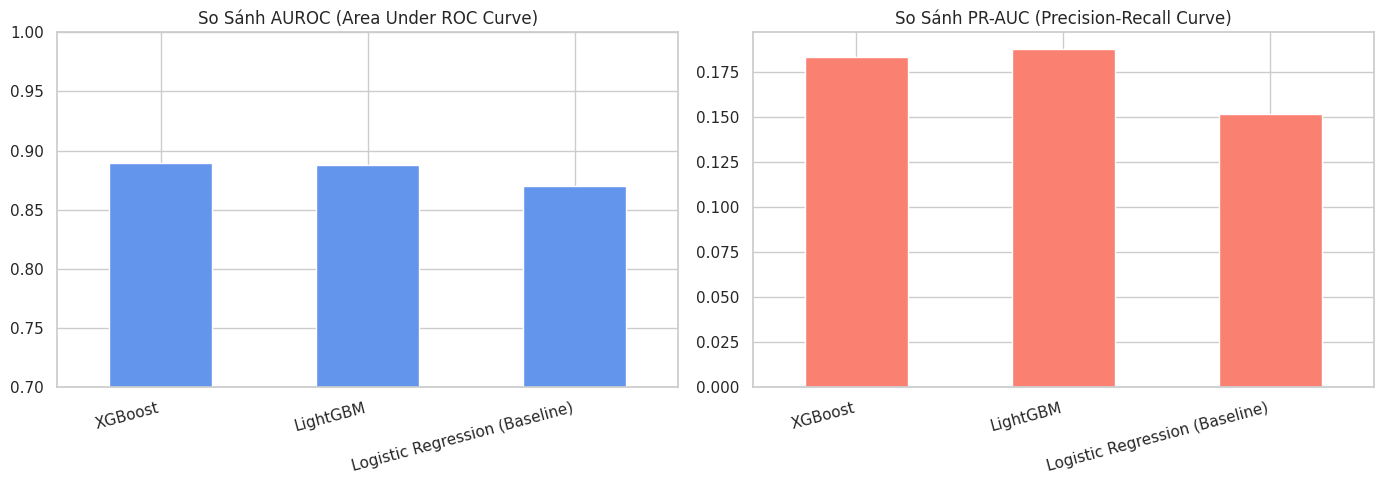

In [4]:
df_results = compare_models(results)
display(df_results)

# Biểu diễn biểu đồ cho AUROC và PR-AUC
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df_results['AUROC'].plot(kind='bar', ax=ax[0], color='cornflowerblue')
ax[0].set_title('So Sánh AUROC (Area Under ROC Curve)')
ax[0].set_ylim(0.7, 1.0)
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=15, ha='right')

df_results['PR-AUC'].plot(kind='bar', ax=ax[1], color='salmon')
ax[1].set_title('So Sánh PR-AUC (Precision-Recall Curve)')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()


## 4. Vẽ Confusion Matrix cho mô hình tốt nhất (Ngưỡng 0.5)


Mô hình tốt nhất là: XGBoost


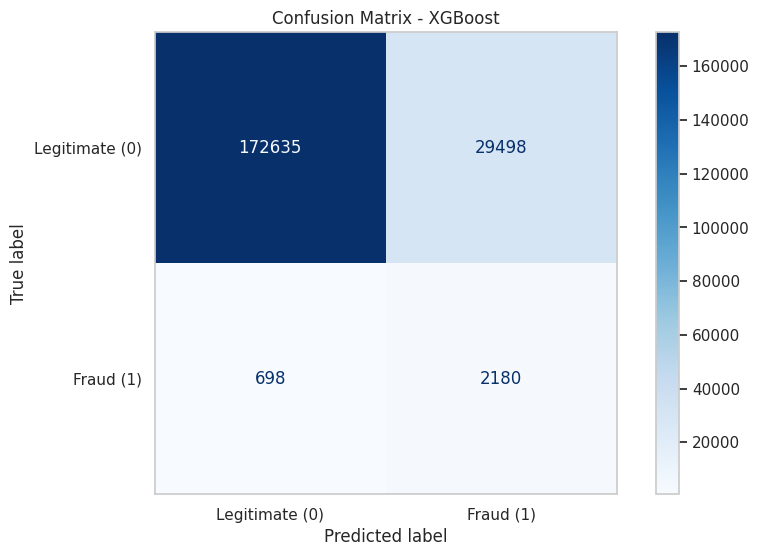

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model_name = df_results.index[0]
print(f"Mô hình tốt nhất là: {best_model_name}")

best_y_proba = y_pred_probas[best_model_name]
best_y_pred = (best_y_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, best_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate (0)', 'Fraud (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.grid(False)
plt.show()


## 5. ROC Curve & Precision-Recall Curve


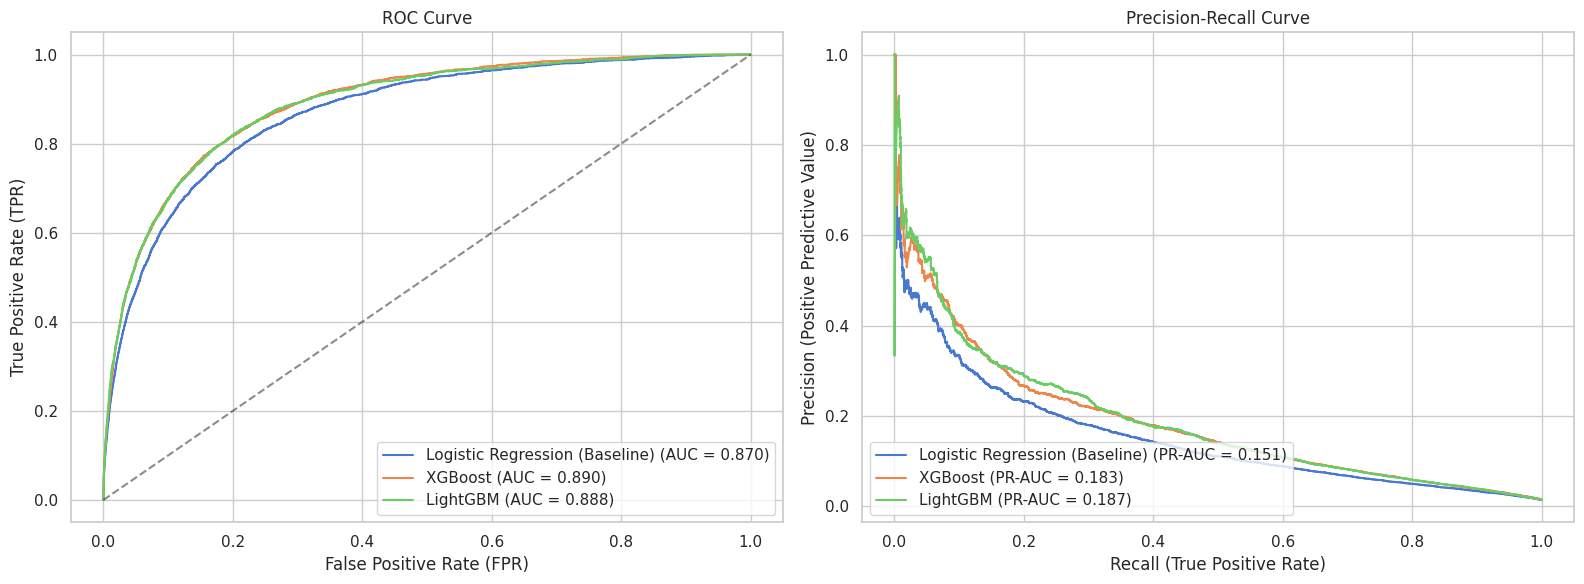

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
for name, probas in y_pred_probas.items():
    fpr, tpr, _ = roc_curve(y_test, probas)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC = {results[name]['AUROC']:.3f})")

ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax[0].set_xlabel('False Positive Rate (FPR)')
ax[0].set_ylabel('True Positive Rate (TPR)')
ax[0].set_title('ROC Curve')
ax[0].legend(loc="lower right")

# Precision-Recall Curve
for name, probas in y_pred_probas.items():
    precision, recall, _ = precision_recall_curve(y_test, probas)
    ax[1].plot(recall, precision, label=f"{name} (PR-AUC = {results[name]['PR-AUC']:.3f})")

ax[1].set_xlabel('Recall (True Positive Rate)')
ax[1].set_ylabel('Precision (Positive Predictive Value)')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend(loc="lower left")

plt.tight_layout()
plt.show()
